# Notebook 1 — Analyse Exploratoire des Données (EDA)
**Health & Lifestyle Dataset** — 100 000 individus, 15 variables


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

df = pd.read_csv('../health_lifestyle_dataset.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (100000, 16)


,id,age,gender,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,smoker,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk
0,1,56,Male,20.5,4198,3.9,3.4,1602,0,0,97,161,111,240,0,0
1,2,69,Female,33.3,14359,9.0,4.7,2346,0,1,68,116,65,207,0,0
2,3,46,Male,31.6,1817,6.6,4.2,1643,0,1,90,123,99,296,0,0
3,4,32,Female,38.2,15772,3.6,2.0,2460,0,0,71,165,95,175,0,0
4,5,60,Female,33.6,6037,3.8,4.0,3756,0,1,98,139,61,294,0,0


## 1. Informations générales

In [2]:
print('=== TYPES ===')
print(df.dtypes)
print('\n=== VALEURS MANQUANTES ===')
print(df.isnull().sum())

=== TYPES ===
id                     int64
age                    int64
gender                   str
bmi                  float64
daily_steps            int64
sleep_hours          float64
water_intake_l       float64
calories_consumed      int64
smoker                 int64
alcohol                int64
resting_hr             int64
systolic_bp            int64
diastolic_bp           int64
cholesterol            int64
family_history         int64
disease_risk           int64
dtype: object

=== VALEURS MANQUANTES ===
id                   0
age                  0
gender               0
bmi                  0
daily_steps          0
sleep_hours          0
water_intake_l       0
calories_consumed    0
smoker               0
alcohol              0
resting_hr           0
systolic_bp          0
diastolic_bp         0
cholesterol          0
family_history       0
disease_risk         0
dtype: int64


## 2. Statistiques descriptives

In [3]:
df.describe().round(2)

,id,age,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,smoker,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk
count,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.0,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00
mean,50000.50,48.53,29.02,10479.87,6.49,2.75,2603.34,0.2,0.30,74.46,134.58,89.51,224.30,0.30,0.25
std,28867.66,17.89,6.35,5483.63,2.02,1.30,807.29,0.4,0.46,14.42,25.95,17.35,43.33,0.46,0.43
min,1.00,18.00,18.00,1000.00,3.00,0.50,1200.00,0.0,0.00,50.00,90.00,60.00,150.00,0.00,0.00
25%,25000.75,33.00,23.50,5729.00,4.70,1.60,1906.00,0.0,0.00,62.00,112.00,74.00,187.00,0.00,0.00
50%,50000.50,48.00,29.00,10468.00,6.50,2.80,2603.00,0.0,0.00,74.00,135.00,89.00,224.00,0.00,0.00
75%,75000.25,64.00,34.50,15229.00,8.20,3.90,3299.00,0.0,1.00,87.00,157.00,105.00,262.00,1.00,0.00
max,100000.00,79.00,40.00,19999.00,10.00,5.00,3999.00,1.0,1.00,99.00,179.00,119.00,299.00,1.00,1.00


## 3. Distribution de la variable cible

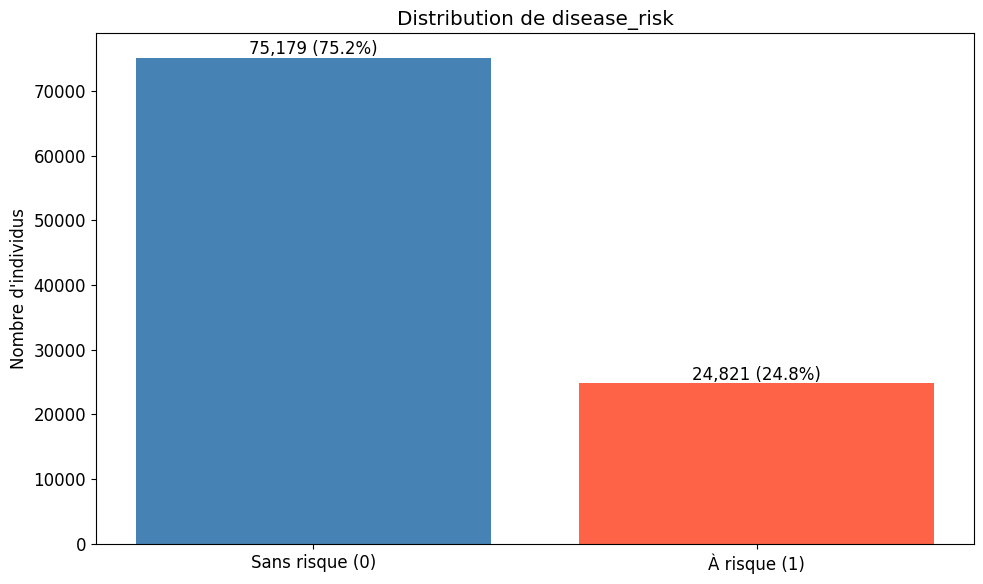

In [4]:
fig, ax = plt.subplots()
counts = df['disease_risk'].value_counts()
ax.bar(['Sans risque (0)', 'À risque (1)'], counts.values, color=['steelblue','tomato'])
ax.set_title('Distribution de disease_risk')
ax.set_ylabel('Nombre d\'individus')
for i, v in enumerate(counts.values):
    ax.text(i, v+500, f'{v:,} ({v/len(df)*100:.1f}%)', ha='center')
plt.tight_layout()
plt.savefig('../figures/disease_risk_distribution.png', dpi=150)
plt.show()

## 4. Distributions des variables continues

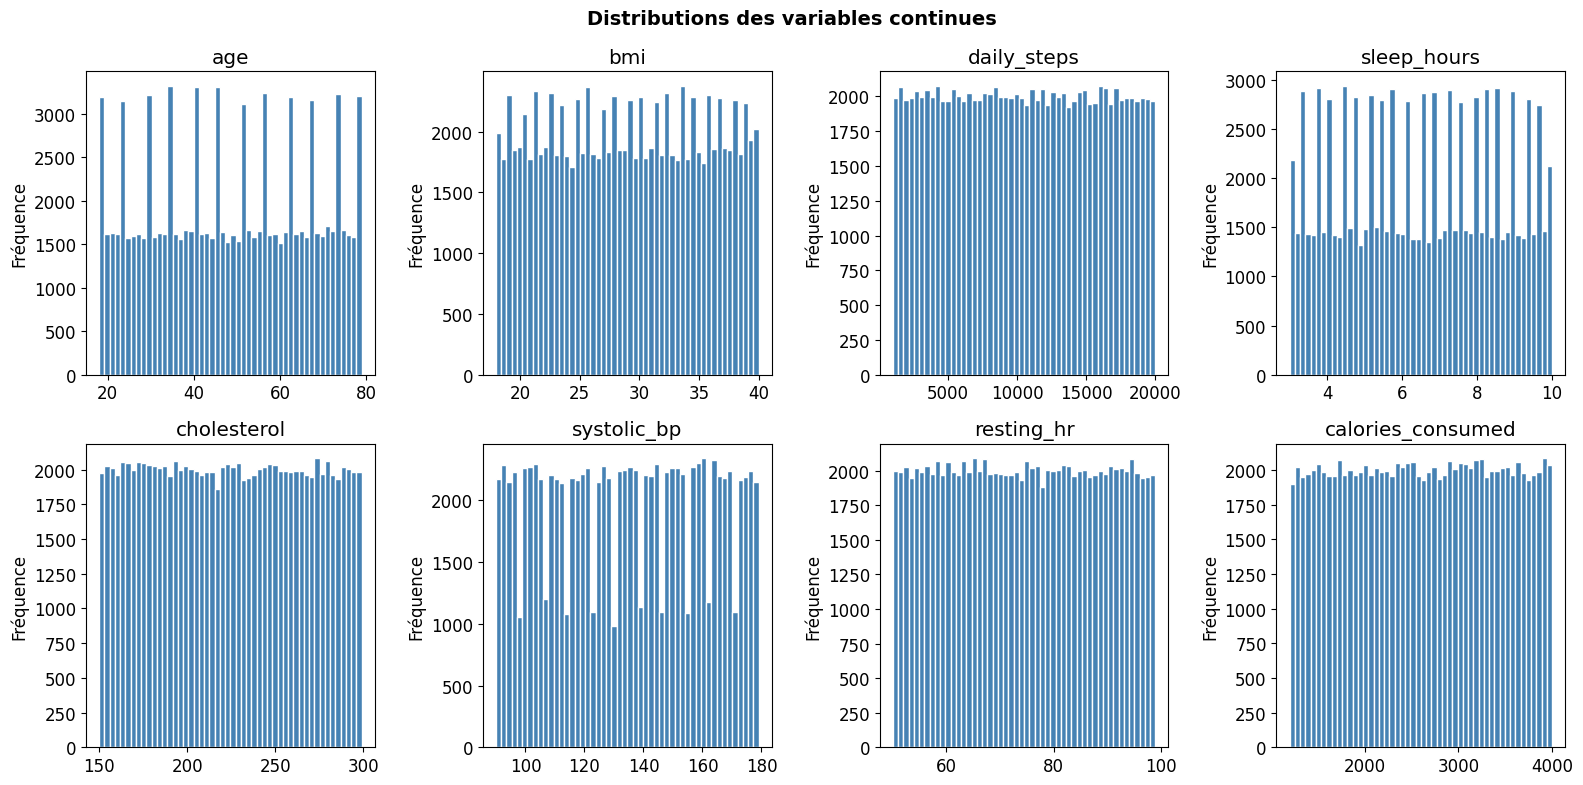

In [5]:
continuous = ['age','bmi','daily_steps','sleep_hours','cholesterol','systolic_bp','resting_hr','calories_consumed']
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flatten(), continuous):
    ax.hist(df[col], bins=50, color='steelblue', edgecolor='white')
    ax.set_title(col)
    ax.set_ylabel('Fréquence')
plt.suptitle('Distributions des variables continues', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/distributions_continues.png', dpi=150)
plt.show()

## 5. Matrice de corrélation

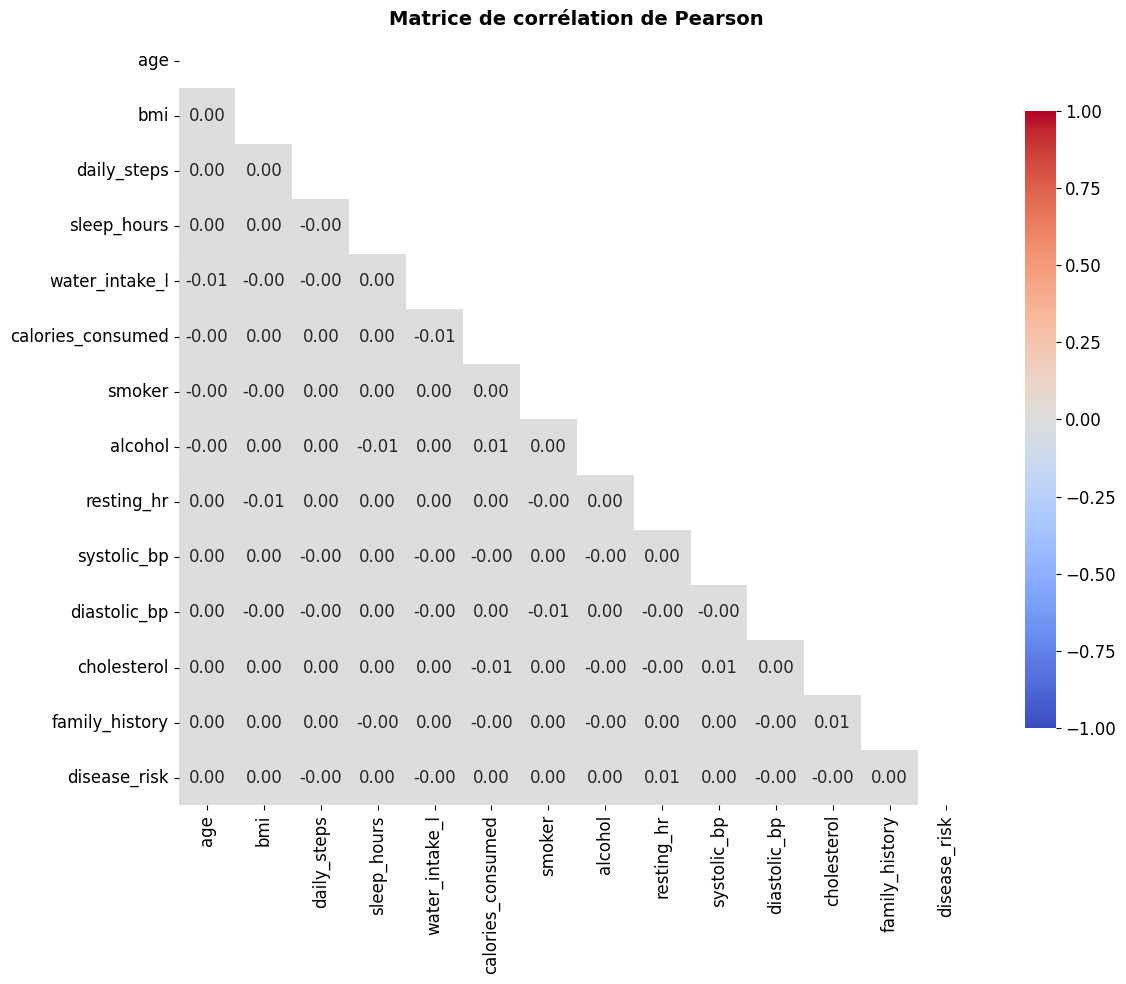

In [6]:
fig, ax = plt.subplots(figsize=(12, 10))
corr = df.select_dtypes(include='number').drop('id', axis=1).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax, cbar_kws={'shrink':0.8})
ax.set_title('Matrice de corrélation de Pearson', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/correlation_matrix.png', dpi=150)
plt.show()

## 6. Corrélations avec disease_risk

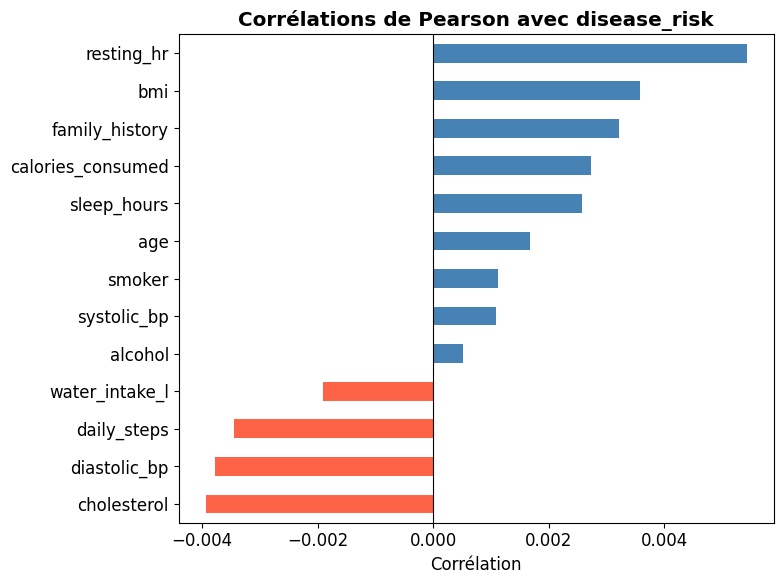

In [7]:
corr_target = df.select_dtypes(include='number').corr()['disease_risk'].drop(['disease_risk','id']).sort_values()
fig, ax = plt.subplots(figsize=(8, 6))
corr_target.plot(kind='barh', ax=ax, color=['tomato' if x < 0 else 'steelblue' for x in corr_target])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Corrélations de Pearson avec disease_risk', fontweight='bold')
ax.set_xlabel('Corrélation')
plt.tight_layout()
plt.savefig('../figures/correlations_target.png', dpi=150)
plt.show()

In [ ]:
# Valeurs exactes utilisées dans le mémoire (section "Résultat central")
corr_target = df.select_dtypes(include='number').corr()['disease_risk'].drop(['disease_risk','id'])
max_corr_var = corr_target.abs().idxmax()
max_corr_val = corr_target[max_corr_var]

print("=== JUSTIFICATION DES VALEURS CITÉES DANS LE MÉMOIRE ===")
print(f"\nCorr. max avec disease_risk : {max_corr_var} → r = {max_corr_val:.4f}")
print(f"Toutes corrélations < |0.01| : {(corr_target.abs() < 0.01).all()}")
print(f"\nSkewness de toutes les variables continues :")
continuous = ['age','bmi','daily_steps','sleep_hours','cholesterol','systolic_bp','resting_hr','calories_consumed']
skew = df[continuous].skew()
print(skew.round(4))
print(f"\nSkewness max (valeur absolue) : {skew.abs().max():.4f} → quasi-uniforme")

## 7. Comparaison des moyennes par groupe disease_risk

In [8]:
cols = ['age','bmi','daily_steps','sleep_hours','cholesterol','systolic_bp','resting_hr']
df.groupby('disease_risk')[cols].mean().round(2)

,age,bmi,daily_steps,sleep_hours,cholesterol,systolic_bp,resting_hr
disease_risk,,,,,,,
0,48.51,29.01,10490.72,6.49,224.4,134.56,74.41
1,48.58,29.06,10447.00,6.50,224.0,134.63,74.59
